# NTC Stock Price Prediction – ITS65704 Data Science Principles

## Step 1: Import Libraries

First we bring in all the libraries we need for the whole notebook. We're using:
- **pandas / numpy** for data handling and maths
- **matplotlib / seaborn** for all our charts
- **sklearn** for the machine learning models, scaling, and validation metrics

In [1]:
# https://www.kaggle.com/datasets/rohankasichhwa/nepse-daily-stock-data-2012-2025?select=NTC.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

# Load the dataset
df_raw = pd.read_csv("NTC.csv")

# .copy() is important here so that any changes we make to df don't affect df_raw
# we keep df_raw as a clean reference throughout the notebook
df = df_raw.copy()

#Predict next day closing price
df['Close_Next_Day'] = df['Close'].shift(-1)
# Drop the last row which will have NaN in 'Close_Next_Day'
df.dropna(inplace=True)

#cheking if close next day shifted price 
print("--- Data Shift Verification ---")
print(df[['Close', 'Close_Next_Day']].head(10))

--- Data Shift Verification ---
    Close  Close_Next_Day
19  439.0           438.0
20  438.0           435.0
21  435.0           433.0
22  433.0           433.0
23  433.0           434.0
24  434.0           435.0
25  435.0           433.0
26  433.0           435.0
27  435.0           435.0
28  435.0           436.0


## Step 2: Type Conversion

Before we can do any analysis, we need to fix two columns that are stored in the wrong format:

1. **Date** is stored as a plain string – we convert it to a proper datetime object so pandas can sort and filter by date
2. **Percent Change** is stored as a string with a ' %' suffix (e.g. '1.18 %'). Some entries also use a dash '-' for days with no change. We strip the suffix, convert to float, and replace any unconvertible values (like '-') with 0.0

In [2]:
# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Strip the ' %' suffix from Percent Change and convert to float
# errors='coerce' turns anything that can't be converted (like '-') into NaN
# fillna(0.0) then replaces those NaN values with 0, since no change = 0%
df['Percent Change'] = pd.to_numeric(
    df['Percent Change'].str.replace(' %', '', regex=False),
    errors='coerce'
).fillna(0.0)

print("Date dtype:", df['Date'].dtype)
print("Percent Change dtype:", df['Percent Change'].dtype)

Date dtype: datetime64[ns]
Percent Change dtype: float64


## Step 3: Initial Data Exploration

Now we take a first look at the dataset to understand its structure – how many rows and columns it has, what data types each column uses, and what the basic statistics look like.

In [3]:
print("Dataset Shape:", df.shape)
print(f"\nThe dataset has {df.shape[0]} rows (trading days) and {df.shape[1]} columns (features)")

Dataset Shape: (3088, 25)

The dataset has 3088 rows (trading days) and 25 columns (features)


In [4]:
# Get a summary of all columns, their data types, and how many non-null values there are
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3088 entries, 19 to 3106
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Symbol          3088 non-null   object        
 1   Date            3088 non-null   datetime64[ns]
 2   Open            3088 non-null   float64       
 3   High            3088 non-null   float64       
 4   Low             3088 non-null   float64       
 5   Close           3088 non-null   float64       
 6   Percent Change  3088 non-null   float64       
 7   Volume          3088 non-null   float64       
 8   Turnover        3088 non-null   float64       
 9   Daily_Return    3088 non-null   float64       
 10  Log_Return      3088 non-null   float64       
 11  SMA_5           3088 non-null   float64       
 12  SMA_20          3088 non-null   float64       
 13  EMA_12          3088 non-null   float64       
 14  EMA_26          3088 non-null   float64       
 15  RSI_14  

In [5]:
# Statistical summary – mean, std, min, max etc for every numeric column
# .T transposes it so it's easier to read
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,3088,2018-11-26 13:14:08.704663040,2012-02-01 00:00:00,2015-07-13 18:00:00,2018-11-27 12:00:00,2022-05-08 06:00:00,2025-08-21 00:00:00,NaN
Open,3088.0,786.145635,400.0,648.0,705.0,875.125,1748.2,224.117799
High,3088.0,794.76012,403.0,651.0,710.0,887.05,1799.9,229.876041
Low,3088.0,775.053941,396.0,640.0,699.0,865.0,1725.0,217.187314
Close,3088.0,784.360664,400.0,647.0,703.0,873.0,1779.0,222.992053
Percent Change,3088.0,0.027251,-9.98,-0.64,0.0,0.61,10.0,1.660764
Volume,3088.0,23796.65285,10.0,2813.75,7727.5,23006.0,433507.0,44144.252293
Turnover,3088.0,24440471.283663,6150.0,1524417.5,4976810.0,19870949.05,604455412.9,54125154.300032
Daily_Return,3088.0,0.000377,-0.201365,-0.00666,0.0,0.006292,0.1,0.017901
Log_Return,3088.0,0.000216,-0.224851,-0.006682,0.0,0.006272,0.09531,0.017923


## Step 4: Checking for Missing Values

We check every column for NaN values. This is important because missing data can cause errors in the model and needs to be handled before we go any further.

In [6]:
# Count missing values in each column
print("Missing values per column:")
print(df.isnull().sum())
#already handled missing values by drop.na in the previous step, so we should see 0 missing values here.

Missing values per column:
Symbol            0
Date              0
Open              0
High              0
Low               0
Close             0
Percent Change    0
Volume            0
Turnover          0
Daily_Return      0
Log_Return        0
SMA_5             0
SMA_20            0
EMA_12            0
EMA_26            0
RSI_14            0
MACD              0
MACD_Signal       0
ATR_14            0
BB_Middle         0
BB_Std            0
BB_Upper          0
BB_Lower          0
OBV               0
Close_Next_Day    0
dtype: int64


In [7]:

# Summary of missing values before and after dropping rows with missing data
print("Original shape:", df_raw.shape)
print("After dropping missing rows:", df.shape)
print(f"Rows removed: {df_raw.shape[0] - df.shape[0]} ({((df_raw.shape[0] - df.shape[0])/df_raw.shape[0]*100):.2f}% of data)")
print("\nMissing values remaining:", df.isnull().sum().sum())

Original shape: (3120, 24)
After dropping missing rows: (3088, 25)
Rows removed: 32 (1.03% of data)

Missing values remaining: 0


## Step 5: Exploratory Data Analysis and Visualisations

We now explore the dataset visually to understand trends, distributions, and relationships between variables. This helps us decide which features to include in the model.

### Figure 1 – NTC Closing Price Over Time

A line chart is the most natural way to look at stock price data. This shows the full price history from 2012 to 2025, making it easy to spot the three market phases: a flat early period, a major bull run, and the correction afterwards.

**Key insight:** The price is clearly non-stationary (it has a trend and changing variance), which is important context for choosing our model.

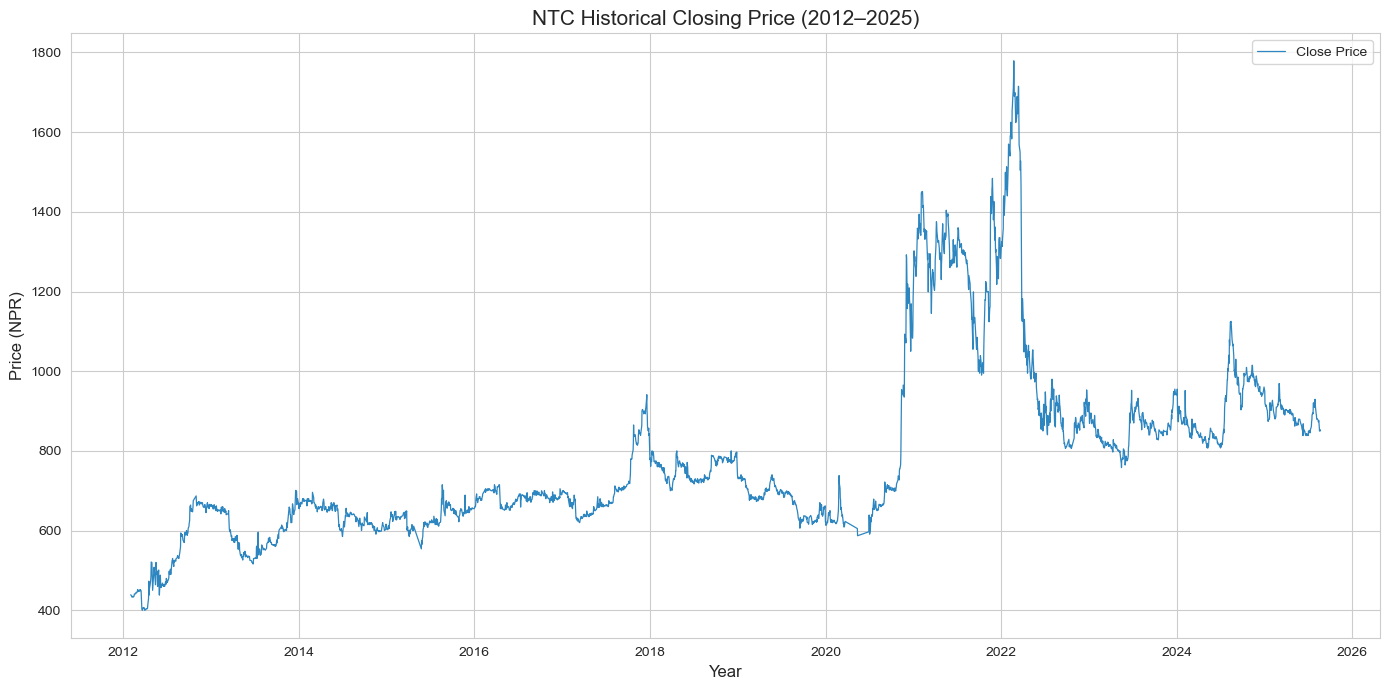

In [8]:
plt.figure()
plt.plot(df['Date'], df['Close'], color='#2E86C1', linewidth=0.9, label='Close Price')
plt.title('NTC Historical Closing Price (2012–2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('ntc_price_history.png', dpi=150)
plt.show()

### Figure 2 – Daily Trading Volume Over Time

This bar chart shows how many shares were traded each day. Trading was thin in the early years but picked up significantly from 2017 onwards as more retail investors entered the NEPSE market.

**Key insight:** Volume spikes often align with major price moves, so Volume is likely to be a useful feature in our model.

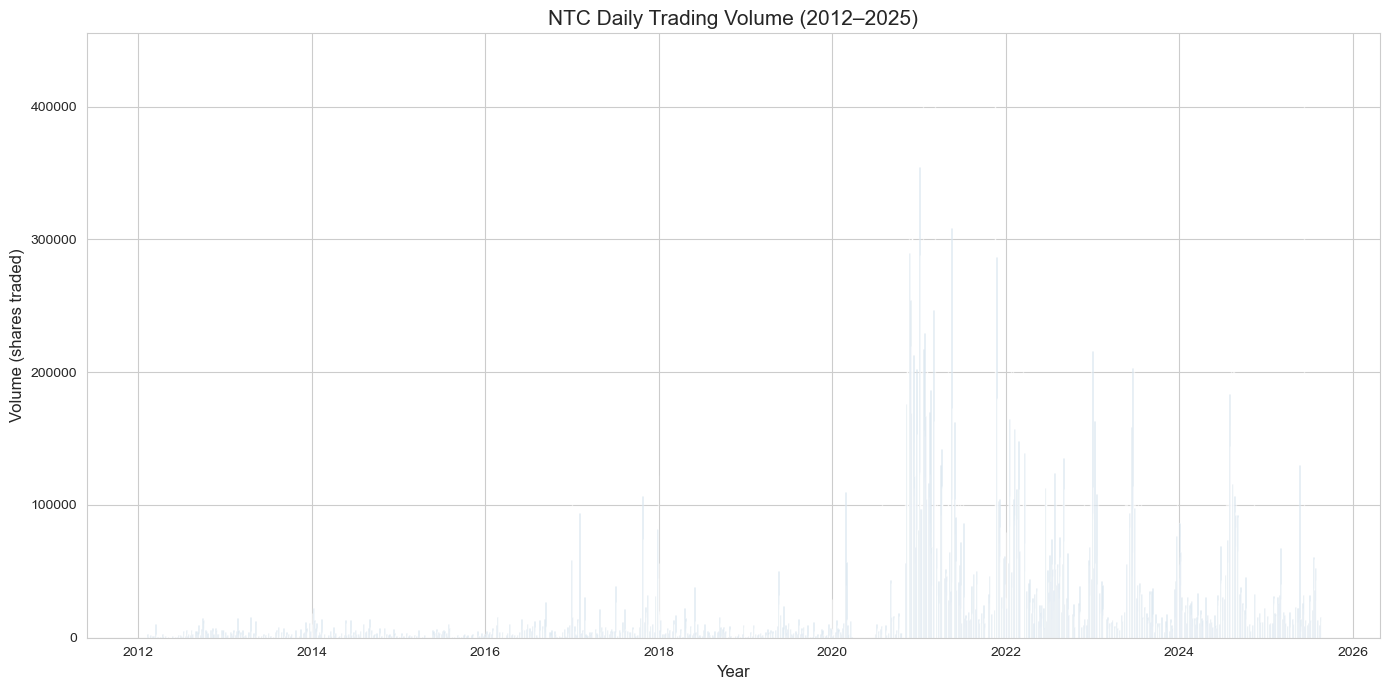

In [9]:
plt.figure()
plt.bar(df['Date'], df['Volume'], color='steelblue', alpha=0.5, width=1)
plt.title('NTC Daily Trading Volume (2012–2025)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Volume (shares traded)', fontsize=12)
plt.tight_layout()
plt.savefig('ntc_volume.png', dpi=150)
plt.show()

### Figure 3 – Distribution of Daily Returns

A histogram with a KDE (Kernel Density Estimate) overlay shows the shape of the daily return distribution. We'd expect it to be roughly bell-shaped and centred near zero.

**Key insight:** The distribution has fat tails, meaning extreme price moves happen more often than a normal distribution would predict. This is a well-known feature of stock return data.

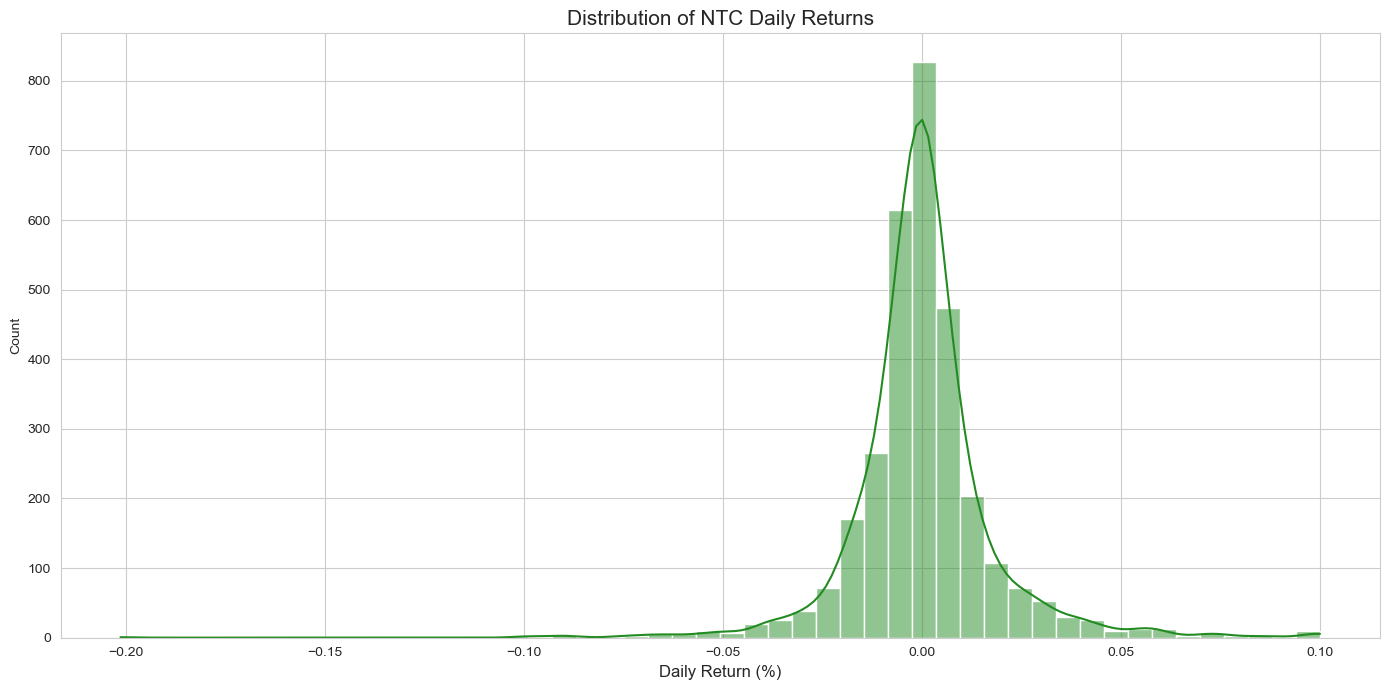

In [10]:
plt.figure()
sns.histplot(df['Daily_Return'], kde=True, bins=50, color='forestgreen')
plt.title('Distribution of NTC Daily Returns', fontsize=15)
plt.xlabel('Daily Return (%)', fontsize=12)
plt.tight_layout()
plt.savefig('ntc_returns_dist.png', dpi=150)
plt.show()

### Figure 4 – Bollinger Bands and SMA (2024–2025)

Instead of plotting Bollinger Bands across the full 13-year dataset (which would be unreadable), we zoom into 2024–2025 where the band behaviour is clearly visible. The shaded area between the upper and lower bands shows the expected price range, and the SMA line shows the short-term trend.

**Key insight:** When the price touches or breaks the upper/lower band it can signal overbought or oversold conditions. This justifies including BB_Upper, BB_Lower and SMA_20 as model features.

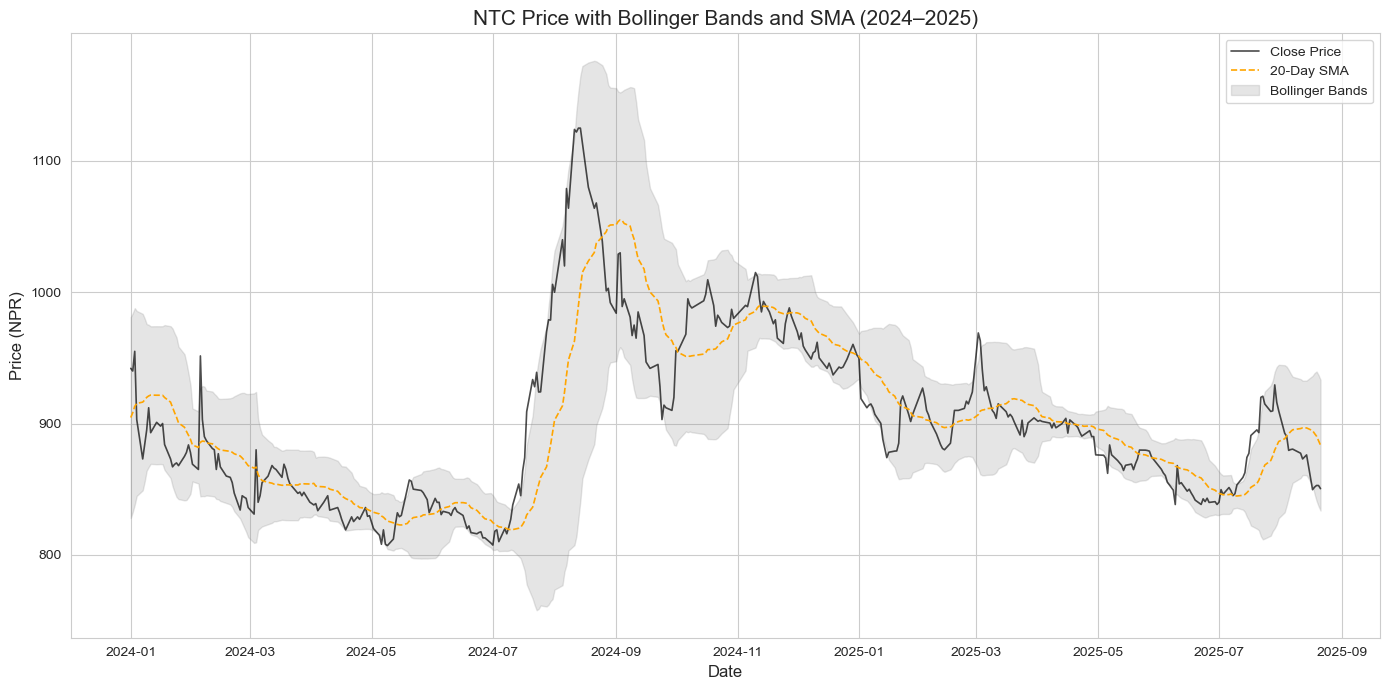

In [11]:
df_recent = df[df['Date'] >= '2024-01-01']

plt.figure()
plt.plot(df_recent['Date'], df_recent['Close'], label='Close Price', color='black', alpha=0.7, linewidth=1.2)
plt.plot(df_recent['Date'], df_recent['SMA_20'], label='20-Day SMA', color='orange', linestyle='--', linewidth=1.2)
plt.fill_between(df_recent['Date'], df_recent['BB_Upper'], df_recent['BB_Lower'],
                 color='gray', alpha=0.2, label='Bollinger Bands')
plt.title('NTC Price with Bollinger Bands and SMA (2024–2025)', fontsize=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('ntc_technical_indicators.png', dpi=150)
plt.show()

### Figure 5 – Feature Correlation Heatmap

A heatmap shows the Pearson correlation between all key numeric features. Values close to 1.0 (dark red) mean the two variables move together strongly; values near 0 mean there's little relationship.

**Key insight:** Open, High, Low and Close are almost perfectly correlated (>0.99). RSI_14 and MACD correlate more with Daily_Return than with price level, which makes them useful for capturing momentum signals independently of price.

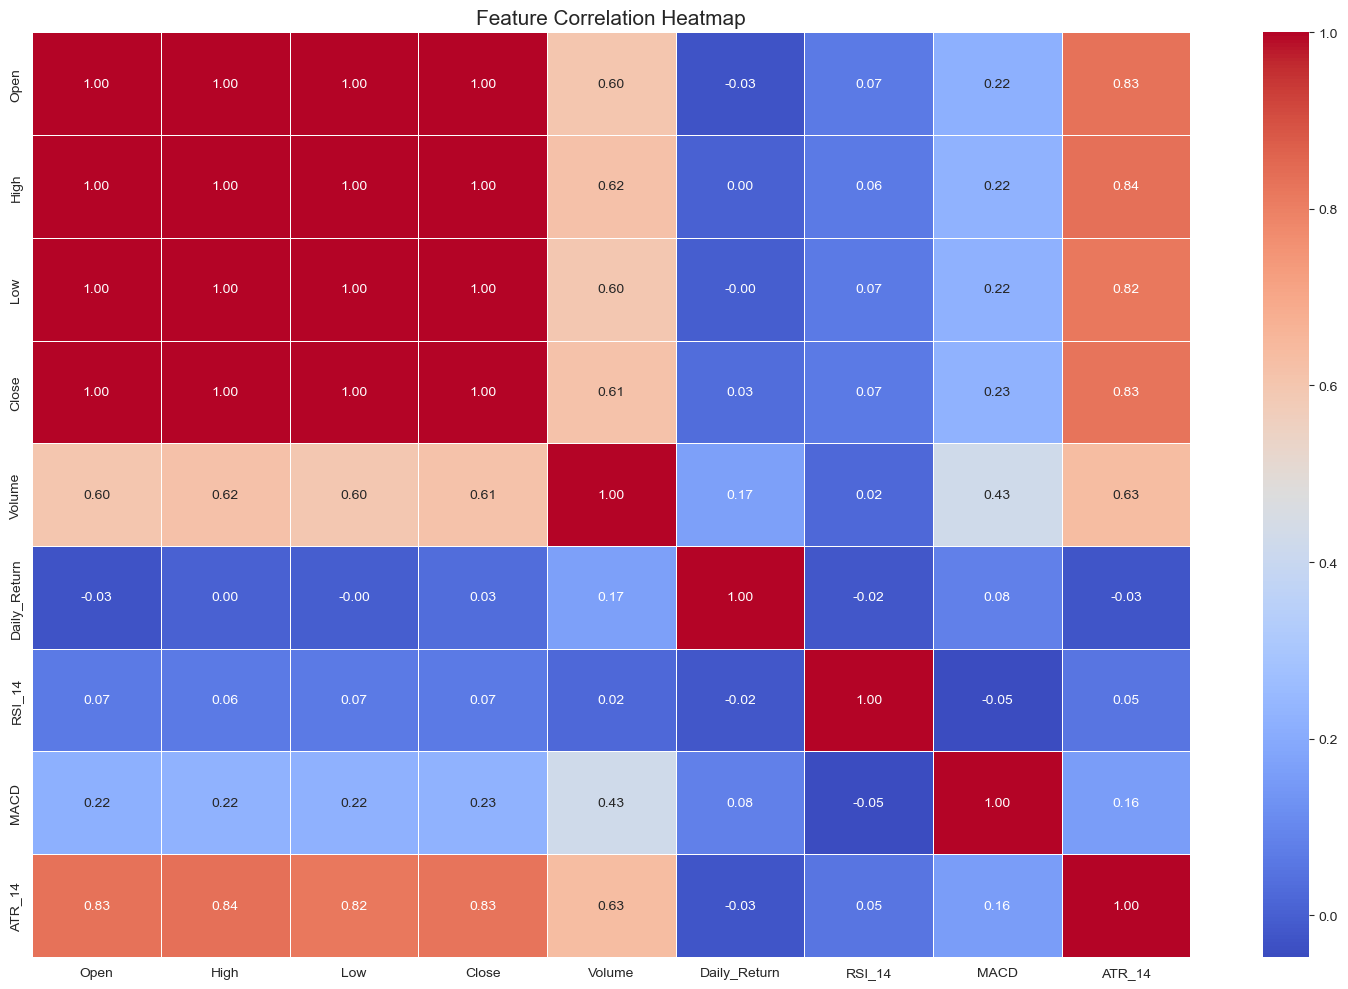

In [12]:
plt.figure(figsize=(15, 10))
features_heatmap = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'RSI_14', 'MACD', 'ATR_14']
sns.heatmap(df[features_heatmap].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('ntc_correlation_heatmap.png', dpi=150)
plt.show()

### Figure 6 – RSI Over Time

The RSI (Relative Strength Index) oscillates between 0 and 100. The red dashed line at 70 marks the overbought threshold, and the green dashed line at 30 marks oversold. Crossings of these lines are traditionally used as buy/sell signals.

**Key insight:** The RSI crossed above 70 multiple times during the 2020–2021 bull run, which in hindsight preceded the correction. This shows RSI carries real predictive signal.

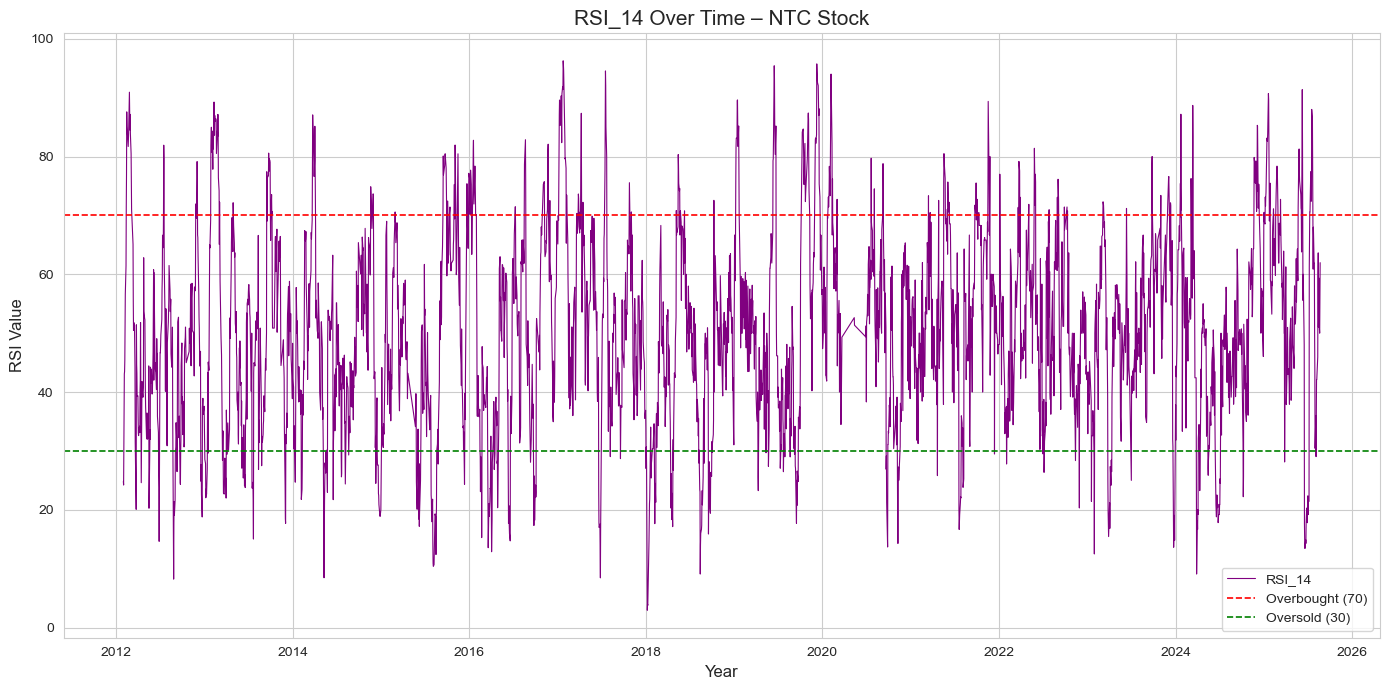

In [13]:
plt.figure()
plt.plot(df['Date'], df['RSI_14'], color='purple', linewidth=0.8, label='RSI_14')
plt.axhline(y=70, color='red', linestyle='--', linewidth=1.2, label='Overbought (70)')
plt.axhline(y=30, color='green', linestyle='--', linewidth=1.2, label='Oversold (30)')
plt.title('RSI_14 Over Time – NTC Stock', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('RSI Value', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('ntc_rsi.png', dpi=150)
plt.show()

## Step 6: Outlier Detection and Handling

Boxplots give us a quick visual view of where outliers are in the key columns. Values beyond the whiskers (1.5x the IQR) are flagged as statistical outliers.

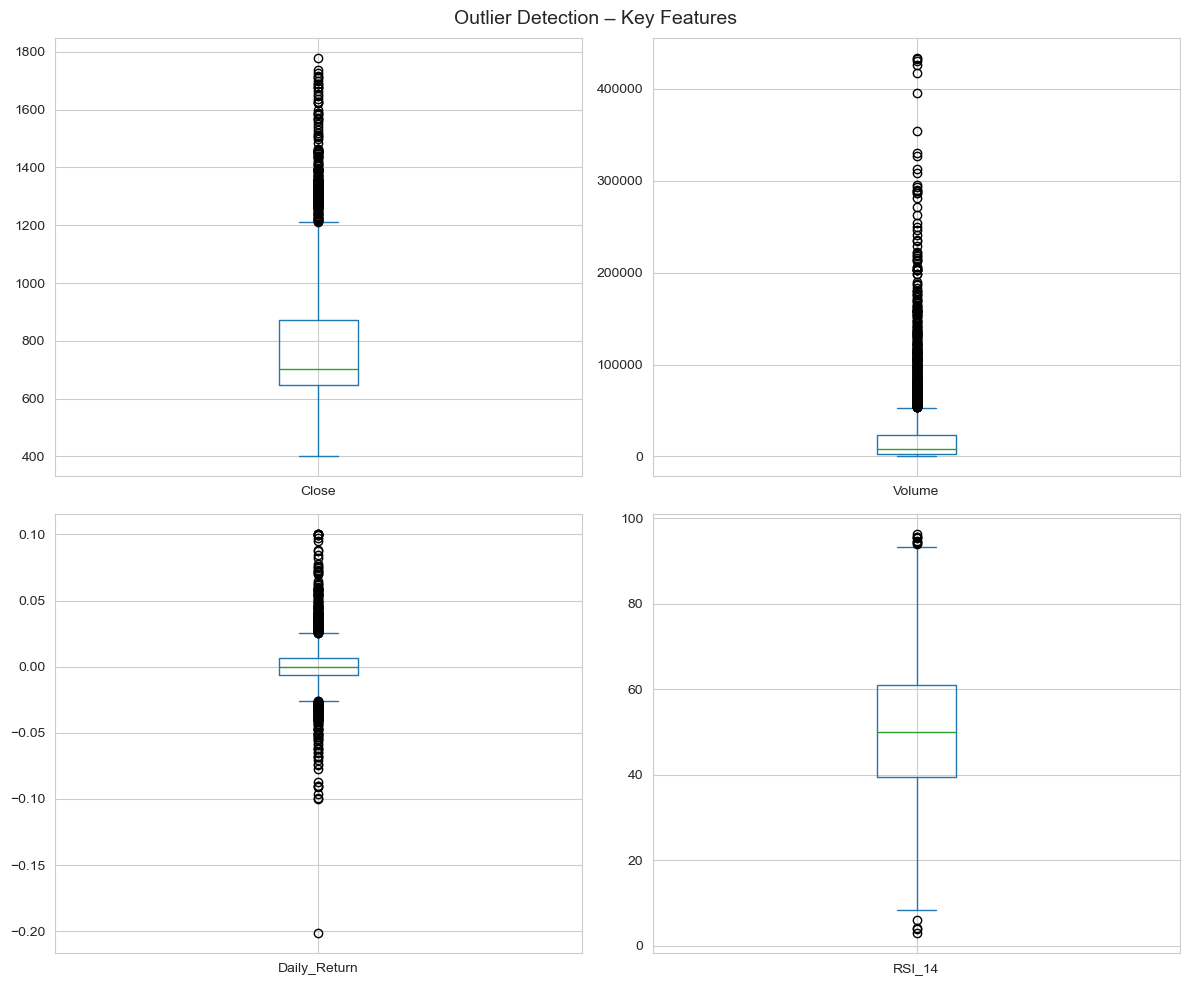

In [14]:
features_to_check = ['Close', 'Volume', 'Daily_Return', 'RSI_14']
df[features_to_check].plot(kind='box', subplots=True, layout=(2, 2), figsize=(12, 10))
plt.suptitle('Outlier Detection – Key Features', fontsize=14)
plt.tight_layout()
plt.show()

### Handling Outliers with Winsorization

For **Volume** and **Daily_Return**, we use Winsorization rather than deleting the outlier rows. The reason is that in stock market data, extreme values often represent real market events (e.g. a news-driven surge or a crash day). Removing those rows entirely would throw away some of the most information-rich observations in the dataset.

Winsorization **caps** values at the 5th and 95th percentile instead of removing them. This softens the extreme values without losing the rows.

For **Close** and **RSI_14** we leave the values untouched because those outliers form part of the price trend we're trying to model.

In [15]:
def apply_winsorization(series, lower_pct=0.05, upper_pct=0.95):
    """
    Caps extreme values at the lower and upper percentile bounds.
    Values below the 5th percentile get set to the 5th percentile value.
    Values above the 95th percentile get set to the 95th percentile value.
    """
    lower_bound = series.quantile(lower_pct)
    upper_bound = series.quantile(upper_pct)
    return series.clip(lower=lower_bound, upper=upper_bound)

cols_to_winsorise = ['Volume', 'Daily_Return']

for col in cols_to_winsorise:
    df.loc[:, col] = apply_winsorization(df[col])

# Verify the capping worked – df_raw is untouched because we used .copy() at the start
print("=== Volume ===")
print(f"  Original max:  {df_raw['Volume'].max():,.0f}")
print(f"  Capped max:    {df['Volume'].max():,.0f}")
print("\n=== Daily_Return ===")
print(f"  Original max:  {df_raw['Daily_Return'].max():.4f}")
print(f"  Capped max:    {df['Daily_Return'].max():.4f}")

=== Volume ===
  Original max:  433,507
  Capped max:    109,550

=== Daily_Return ===
  Original max:  0.1000
  Capped max:    0.0286


## Step 7: Feature Selection, Train-Test Split, and Scaling

### 7.1 Feature Selection

Not all 24 columns are useful as model inputs. We selected features based on two criteria:
1. They should not be fully redundant with each other (to avoid multicollinearity)
2. They should capture something meaningful – price direction, momentum, or volatility

We chose: `Open`, `High`, `Low`, `Volume`, `Daily_Return`, `SMA_20`, `EMA_26`, `RSI_14`, `MACD`, `ATR_14`

We excluded:
- **Symbol** – identical in every row, adds zero information
- **Date** – used for ordering only, not a numeric feature
- **Close** – this is our target variable (y), not an input feature
- **Redundant price columns** (Turnover, Log_Return, SMA_5, EMA_12) – highly correlated with features already included

### 7.2 Train-Test Split (Chronological)

We split the data **80% train / 20% test**, keeping the rows in chronological order. We do NOT use a random shuffle because this is time series data.

A random shuffle would allow the model to train on data from 2023 and then be tested on data from 2015, which makes no sense – a model can't know the future. The chronological split means the model trains only on past data and is tested on genuinely unseen future data.

### 7.3 Min-Max Normalisation

The features operate on very different scales – for example, Volume can be in the tens of thousands while RSI is always between 0 and 100. Without scaling, models like Linear Regression can be biased towards features with larger raw values.

Min-Max scaling maps every feature to the range [0, 1]. **Critically, we fit the scaler on the training set only and then apply it to the test set.** Fitting on the test set too would leak information about the test period into the training process.

In [16]:
# --- Feature Selection ---
features = ['Open', 'Volume', 'Daily_Return', 'SMA_20', 'EMA_26', 'RSI_14', 'MACD', 'ATR_14']
X = df[features]
y = df['Close_Next_Day']

# --- Chronological Train-Test Split (80/20) ---
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {len(X_train)} rows  ({X_train.index[0]} to {X_train.index[-1]})")
print(f"Test set:     {len(X_test)} rows  ({X_test.index[0]} to {X_test.index[-1]})")

# --- Min-Max Scaling ---
# Fit ONLY on training data, then transform both sets
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)          # transform only, no fit

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

print(f"\nFeatures scaled to range: [{X_train_scaled.min():.1f}, {X_train_scaled.max():.1f}]")

Training set: 2470 rows  (19 to 2488)
Test set:     618 rows  (2489 to 3106)

Features scaled to range: [0.0, 1.0]


## Step 8: Cross-Validation Using TimeSeriesSplit

Before training our final models, we use **TimeSeriesSplit** to get a more reliable estimate of how well each model performs. This is the correct form of cross-validation for time series data.

Unlike standard k-fold cross-validation (which randomly shuffles the data), TimeSeriesSplit always keeps the training data before the validation data in time. Each fold expands the training window and tests on the next chunk of future data, which is the only realistic way to evaluate a prediction model.

We use 5 folds and record the RMSE for each fold to see how stable the model performance is across different time periods.

In [17]:
tscv = TimeSeriesSplit(n_splits=5)

print("=== TimeSeriesSplit Cross-Validation ===")
print(f"Number of folds: 5\n")

for model_name, model_cv in [('Linear Regression', LinearRegression()),
                               ('Random Forest',     RandomForestRegressor(n_estimators=100, random_state=42))]:
    fold_rmses = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled), 1):
        X_fold_train, X_fold_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
        y_fold_train = y_train_scaled[train_idx].ravel()
        y_fold_val   = y_train_scaled[val_idx].ravel()

        model_cv.fit(X_fold_train, y_fold_train)
        y_fold_pred = model_cv.predict(X_fold_val)

        # Convert scaled predictions back to NPR for interpretable RMSE
        y_fold_pred_npr = scaler_y.inverse_transform(y_fold_pred.reshape(-1, 1)).flatten()
        y_fold_val_npr  = scaler_y.inverse_transform(y_fold_val.reshape(-1, 1)).flatten()

        fold_rmse = np.sqrt(mean_squared_error(y_fold_val_npr, y_fold_pred_npr))
        fold_rmses.append(fold_rmse)

    print(f"{model_name}:")
    for i, r in enumerate(fold_rmses, 1):
        print(f"  Fold {i} RMSE: NPR {r:.2f}")
    print(f"  Mean RMSE: NPR {np.mean(fold_rmses):.2f}  |  Std: NPR {np.std(fold_rmses):.2f}\n")

=== TimeSeriesSplit Cross-Validation ===
Number of folds: 5

Linear Regression:
  Fold 1 RMSE: NPR 10.95
  Fold 2 RMSE: NPR 8.46
  Fold 3 RMSE: NPR 11.47
  Fold 4 RMSE: NPR 30.36
  Fold 5 RMSE: NPR 37.82
  Mean RMSE: NPR 19.81  |  Std: NPR 11.94

Random Forest:
  Fold 1 RMSE: NPR 14.66
  Fold 2 RMSE: NPR 15.28
  Fold 3 RMSE: NPR 85.04
  Fold 4 RMSE: NPR 193.15
  Fold 5 RMSE: NPR 104.24
  Mean RMSE: NPR 82.47  |  Std: NPR 66.10



## Step 9: Model 1 – Linear Regression

Linear Regression is our **baseline model**. It assumes a straight-line (linear) relationship between the input features and the target variable. It's fast to train, easy to interpret, and gives us a benchmark to compare more complex models against.

The model learns a weight (coefficient) for each feature, and the prediction is the weighted sum of all inputs. If it performs well, it means the relationship between the technical indicators and price is largely linear. If it doesn't, we'll need the more flexible Random Forest.

In [18]:
# Train Linear Regression on the full training set
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train_scaled.ravel())

# Predict on the test set
y_pred_scaled_lr = lr_model.predict(X_test_scaled)

# Convert predictions back to real NPR prices
# .flatten() ensures both arrays are 1D so metrics calculate correctly
y_pred_lr = scaler_y.inverse_transform(y_pred_scaled_lr.reshape(-1, 1)).flatten()
y_actual  = scaler_y.inverse_transform(y_test_scaled).flatten()

# Evaluation metrics
mae_lr  = mean_absolute_error(y_actual, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_actual, y_pred_lr))
r2_lr   = r2_score(y_actual, y_pred_lr)

print("=" * 40)
print("   LINEAR REGRESSION – TEST SET RESULTS")
print("=" * 40)
print(f"  MAE:       NPR {mae_lr:.2f}")
print(f"  RMSE:      NPR {rmse_lr:.2f}")
print(f"  R² Score:  {r2_lr:.4f}")
print("=" * 40)

   LINEAR REGRESSION – TEST SET RESULTS
  MAE:       NPR 11.23
  RMSE:      NPR 15.77
  R² Score:  0.9324


In [19]:
forecast_results = pd.DataFrame({
    'Actual_Price_Next_Day': y_test,
    'Predicted_Price_Next_Day': y_pred_lr 
})

print("--- Final Model Predictions (Last 15 Days) ---")
print(forecast_results.tail(15))

--- Final Model Predictions (Last 15 Days) ---
      Actual_Price_Next_Day  Predicted_Price_Next_Day
3092                 892.57                912.958325
3093                 890.26                898.800211
3094                 879.54                907.422163
3095                 880.16                887.767515
3096                 880.49                894.242552
3097                 877.37                884.301015
3098                 872.99                879.397523
3099                 874.58                865.477579
3100                 876.08                870.898684
3101                 849.61                874.314065
3102                 851.52                841.411476
3103                 852.81                850.798026
3104                 852.79                856.597532
3105                 850.40                847.325179
3106                 852.12                851.670952


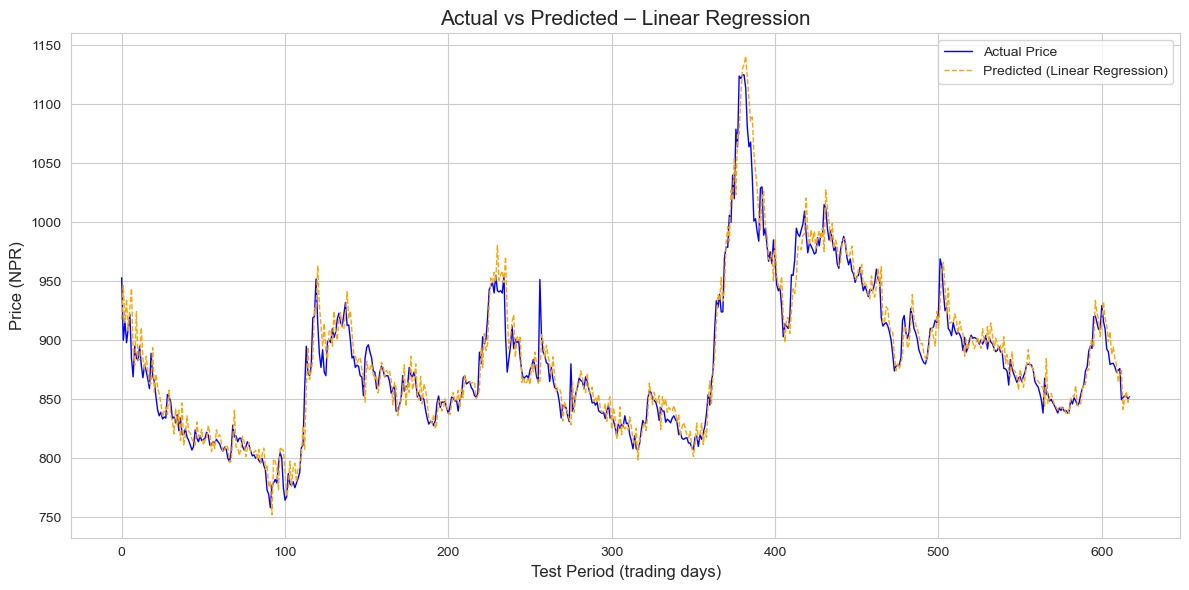

In [20]:
# Plot actual vs predicted prices for Linear Regression
plt.figure(figsize=(12, 6))
plt.plot(y_actual, label='Actual Price', color='blue', linewidth=1)
plt.plot(y_pred_lr, label='Predicted (Linear Regression)', color='orange', linestyle='--', linewidth=1)
plt.title('Actual vs Predicted – Linear Regression', fontsize=15)
plt.xlabel('Test Period (trading days)', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Step 10: Model 2 – Random Forest Regressor

Random Forest is an **ensemble model** – it builds many decision trees (100 in our case) and averages their predictions. This makes it much more robust than a single decision tree and far less likely to overfit.

The key advantage over Linear Regression is that Random Forest can capture **non-linear relationships** between features and the target. Stock prices don't move in straight lines – they're influenced by complex combinations of signals – so a non-linear model is likely to perform better here.

We use `n_estimators=100` (100 trees) and `random_state=42` (for reproducibility). The feature importance plot after training will also tell us which features the model found most useful.

In [21]:
# Train Random Forest on the full training set
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_scaled.ravel())

# Predict on the test set
y_pred_scaled_rf = rf_model.predict(X_test_scaled)

# Convert predictions back to real NPR prices
y_pred_rf = scaler_y.inverse_transform(y_pred_scaled_rf.reshape(-1, 1)).flatten()

# Evaluation metrics
mae_rf  = mean_absolute_error(y_actual, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_actual, y_pred_rf))
r2_rf   = r2_score(y_actual, y_pred_rf)

print("=" * 40)
print("   RANDOM FOREST – TEST SET RESULTS")
print("=" * 40)
print(f"  MAE:       NPR {mae_rf:.2f}")
print(f"  RMSE:      NPR {rmse_rf:.2f}")
print(f"  R² Score:  {r2_rf:.4f}")
print("=" * 40)

   RANDOM FOREST – TEST SET RESULTS
  MAE:       NPR 18.20
  RMSE:      NPR 25.40
  R² Score:  0.8247


In [22]:
forecast_results = pd.DataFrame({
    'Actual_Price_Next_Day': y_test,
    'Predicted_Price_Next_Day': y_pred_rf 
})

print("--- Final Model Predictions (Last 15 Days) ---")
print(forecast_results.tail(15))

--- Final Model Predictions (Last 15 Days) ---
      Actual_Price_Next_Day  Predicted_Price_Next_Day
3092                 892.57                   911.094
3093                 890.26                   905.657
3094                 879.54                   906.638
3095                 880.16                   873.295
3096                 880.49                   877.987
3097                 877.37                   868.380
3098                 872.99                   868.424
3099                 874.58                   868.987
3100                 876.08                   871.446
3101                 849.61                   870.000
3102                 851.52                   866.878
3103                 852.81                   846.168
3104                 852.79                   873.353
3105                 850.40                   861.264
3106                 852.12                   872.574


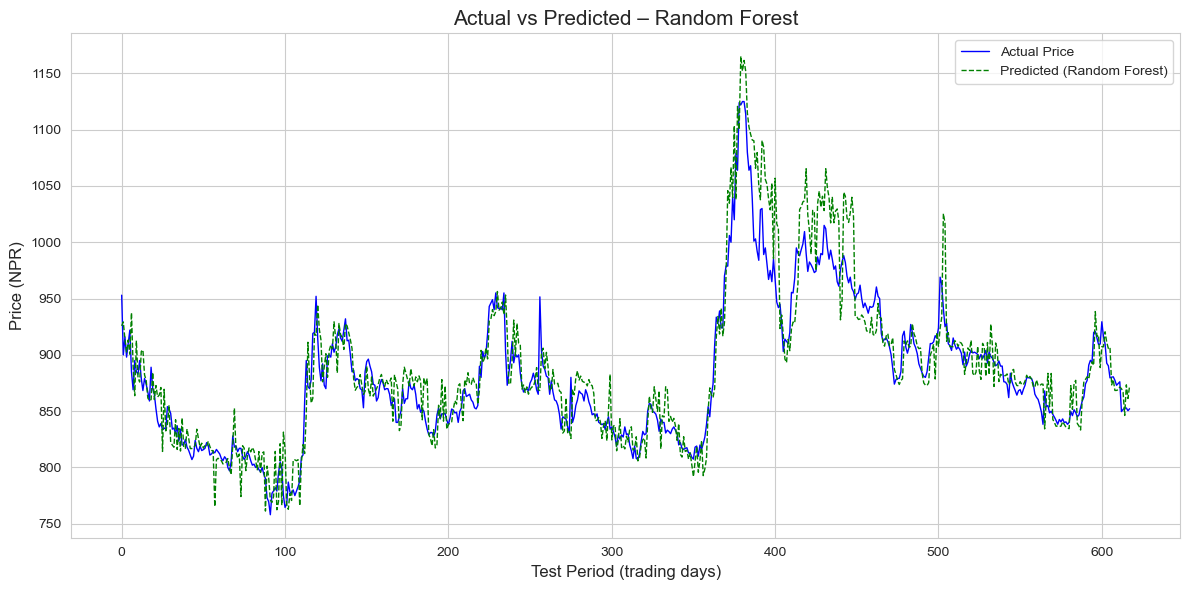

In [23]:
# Plot actual vs predicted prices for Random Forest
plt.figure(figsize=(12, 6))
plt.plot(y_actual, label='Actual Price', color='blue', linewidth=1)
plt.plot(y_pred_rf, label='Predicted (Random Forest)', color='green', linestyle='--', linewidth=1)
plt.title('Actual vs Predicted – Random Forest', fontsize=15)
plt.xlabel('Test Period (trading days)', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)

One of the advantages of Random Forest is that it tells us how much each feature contributed to the predictions. Features with higher importance scores had a bigger influence on the model's decisions.

This helps us answer one of our sub-questions from Part 5: *which technical indicators are the most useful for predicting price?*

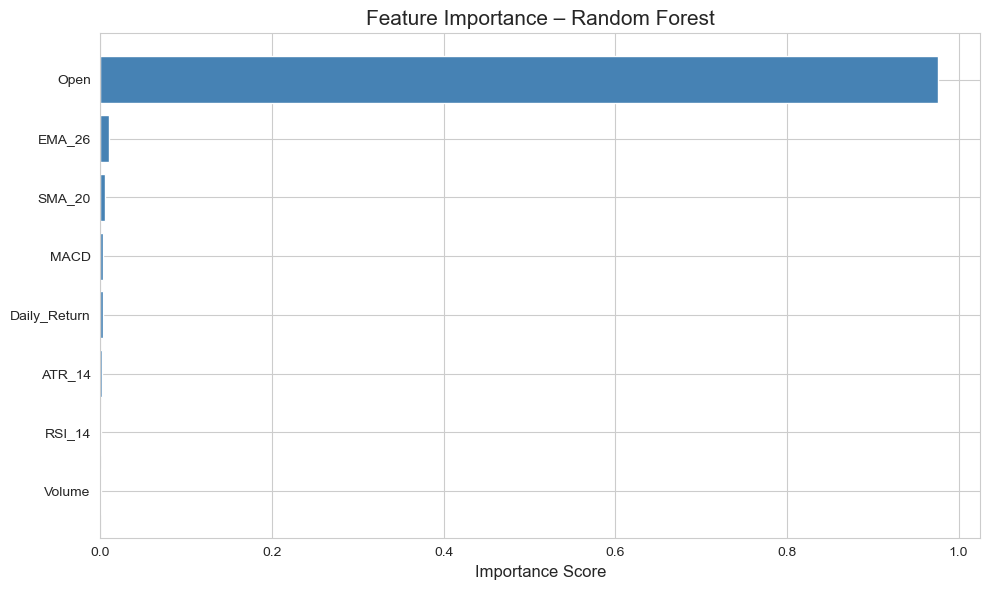

     Feature  Importance
        Open    0.976107
      EMA_26    0.009893
      SMA_20    0.004715
        MACD    0.003206
Daily_Return    0.002874
      ATR_14    0.001421
      RSI_14    0.001097
      Volume    0.000687


In [24]:
# Extract feature importances from the trained Random Forest
importances = rf_model.feature_importances_
feat_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='steelblue')
plt.title('Feature Importance – Random Forest', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()

print(feat_df.sort_values('Importance', ascending=False).to_string(index=False))

## Step 11: Model Comparison and Validation Summary

Now we compare both models side by side using all three metrics:

- **MAE (Mean Absolute Error)** – average difference between predicted and actual price in NPR. Lower is better.
- **RMSE (Root Mean Squared Error)** – similar to MAE but penalises larger errors more heavily. Lower is better.
- **R² Score** – how much of the variance in the actual price the model explains. Closer to 1.0 is better.

We also summarise the cross-validation results to show how stable each model is across different time periods.

In [25]:
# Side-by-side comparison table
results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest'],
    'MAE (NPR)':  [round(mae_lr, 2),  round(mae_rf, 2)],
    'RMSE (NPR)': [round(rmse_lr, 2), round(rmse_rf, 2)],
    'R² Score':   [round(r2_lr, 4),   round(r2_rf, 4)]
})

print("\n=== FINAL MODEL COMPARISON ===")
print(results.to_string(index=False))
print("\nBetter model (lower RMSE):",
      'Linear Regression' if rmse_lr < rmse_rf else 'Random Forest')


=== FINAL MODEL COMPARISON ===
            Model  MAE (NPR)  RMSE (NPR)  R² Score
Linear Regression      11.23       15.77    0.9324
    Random Forest      18.20       25.40    0.8247

Better model (lower RMSE): Linear Regression


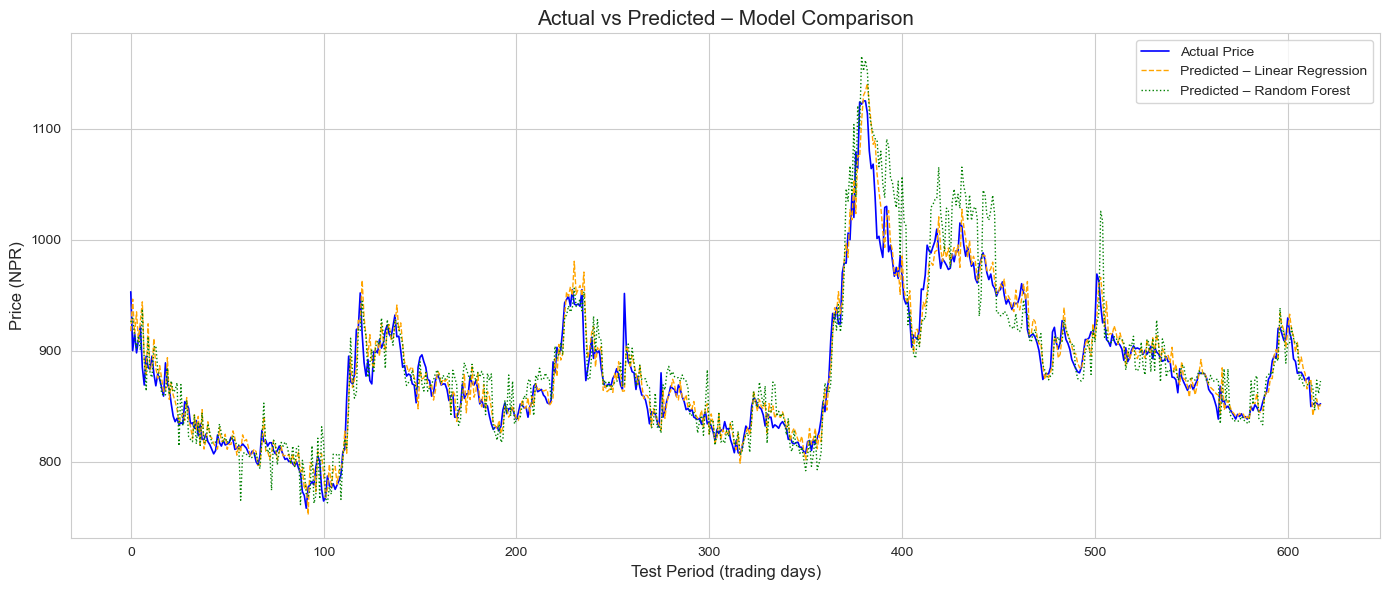

In [26]:
# Visual comparison – both predictions on the same chart
plt.figure(figsize=(14, 6))
plt.plot(y_actual,  label='Actual Price',                  color='blue',   linewidth=1.2)
plt.plot(y_pred_lr, label='Predicted – Linear Regression', color='orange', linestyle='--', linewidth=1)
plt.plot(y_pred_rf, label='Predicted – Random Forest',     color='green',  linestyle=':',  linewidth=1)
plt.title('Actual vs Predicted – Model Comparison', fontsize=15)
plt.xlabel('Test Period (trading days)', fontsize=12)
plt.ylabel('Price (NPR)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## Summary

This notebook covered the full data science pipeline for NTC stock price prediction:

1. **Data Loading and Type Conversion** – fixed the Date and Percent Change columns
2. **Missing Value Handling** – dropped the first ~19 rows caused by indicator look-back windows
3. **EDA and Visualisations** – 6 charts covering price trends, volume, return distribution, Bollinger Bands, correlation, and RSI
4. **Outlier Handling** – applied Winsorization to Volume and Daily_Return
5. **Feature Selection, Scaling, and Splitting** – chronological 80/20 split, Min-Max scaling fitted on train only
6. **Cross-Validation** – TimeSeriesSplit (5 folds) to evaluate stability across time periods
7. **Model 1: Linear Regression** – baseline model with MAE, RMSE, R²
8. **Model 2: Random Forest** – non-linear ensemble model with feature importance analysis
9. **Model Comparison** – side-by-side evaluation of both models